In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv(r'data\Life Expectancy Data.csv')
pd.set_option('display.float_format', '{:.2f}'.format)
df.columns = df.columns.str.strip()

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
print(df.shape)
df.head(16)

(2938, 22)


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.00,263.00,62,0.01,71.28,65.00,1154,19.10,83,6.00,8.16,65.00,0.10,584.26,33736494.00,17.20,17.30,0.48,10.10
1,Afghanistan,2014,Developing,59.90,271.00,64,0.01,73.52,62.00,492,18.60,86,58.00,8.18,62.00,0.10,612.70,327582.00,17.50,17.50,0.48,10.00
2,Afghanistan,2013,Developing,59.90,268.00,66,0.01,73.22,64.00,430,18.10,89,62.00,8.13,64.00,0.10,631.74,31731688.00,17.70,17.70,0.47,9.90
3,Afghanistan,2012,Developing,59.50,272.00,69,0.01,78.18,67.00,2787,17.60,93,67.00,8.52,67.00,0.10,669.96,3696958.00,17.90,18.00,0.46,9.80
4,Afghanistan,2011,Developing,59.20,275.00,71,0.01,7.10,68.00,3013,17.20,97,68.00,7.87,68.00,0.10,63.54,2978599.00,18.20,18.20,0.45,9.50
5,Afghanistan,2010,Developing,58.80,279.00,74,0.01,79.68,66.00,1989,16.70,102,66.00,9.20,66.00,0.10,553.33,2883167.00,18.40,18.40,0.45,9.20
6,Afghanistan,2009,Developing,58.60,281.00,77,0.01,56.76,63.00,2861,16.20,106,63.00,9.42,63.00,0.10,445.89,284331.00,18.60,18.70,0.43,8.90
7,Afghanistan,2008,Developing,58.10,287.00,80,0.03,25.87,64.00,1599,15.70,110,64.00,8.33,64.00,0.10,373.36,2729431.00,18.80,18.90,0.43,8.70
8,Afghanistan,2007,Developing,57.50,295.00,82,0.02,10.91,63.00,1141,15.20,113,63.00,6.73,63.00,0.10,369.84,26616792.00,19.00,19.10,0.41,8.40
9,Afghanistan,2006,Developing,57.30,295.00,84,0.03,17.17,64.00,1990,14.70,116,58.00,7.43,58.00,0.10,272.56,2589345.00,19.20,19.30,0.41,8.10


In [2]:
from scipy.stats import skew
rows = []
for col in df.select_dtypes(include='number').columns:
    s = df[col]
    rows.append({
    'column': col,
    'min': s.min(),
    'max': s.max(),
    'std': s.std(),
    'mean': s.mean(),
    'median': s.median(),
    'skewness': skew(s, nan_policy='omit'),
    'na_count': s.isna().sum(),
    'null_pct': round(s.isna().mean() * 100, 2),
})

result = pd.DataFrame(rows).set_index('column')
print(result)

                                    min           max         std        mean  \
column                                                                          
Year                            2000.00       2015.00        4.61     2007.52   
Life expectancy                   36.30         89.00        9.52       69.22   
Adult Mortality                    1.00        723.00      124.29      164.80   
infant deaths                      0.00       1800.00      117.93       30.30   
Alcohol                            0.01         17.87        4.05        4.60   
percentage expenditure             0.00      19479.91     1987.91      738.25   
Hepatitis B                        1.00         99.00       25.07       80.94   
Measles                            0.00     212183.00    11467.27     2419.59   
BMI                                1.00         87.30       20.04       38.32   
under-five deaths                  0.00       2500.00      160.45       42.04   
Polio                       

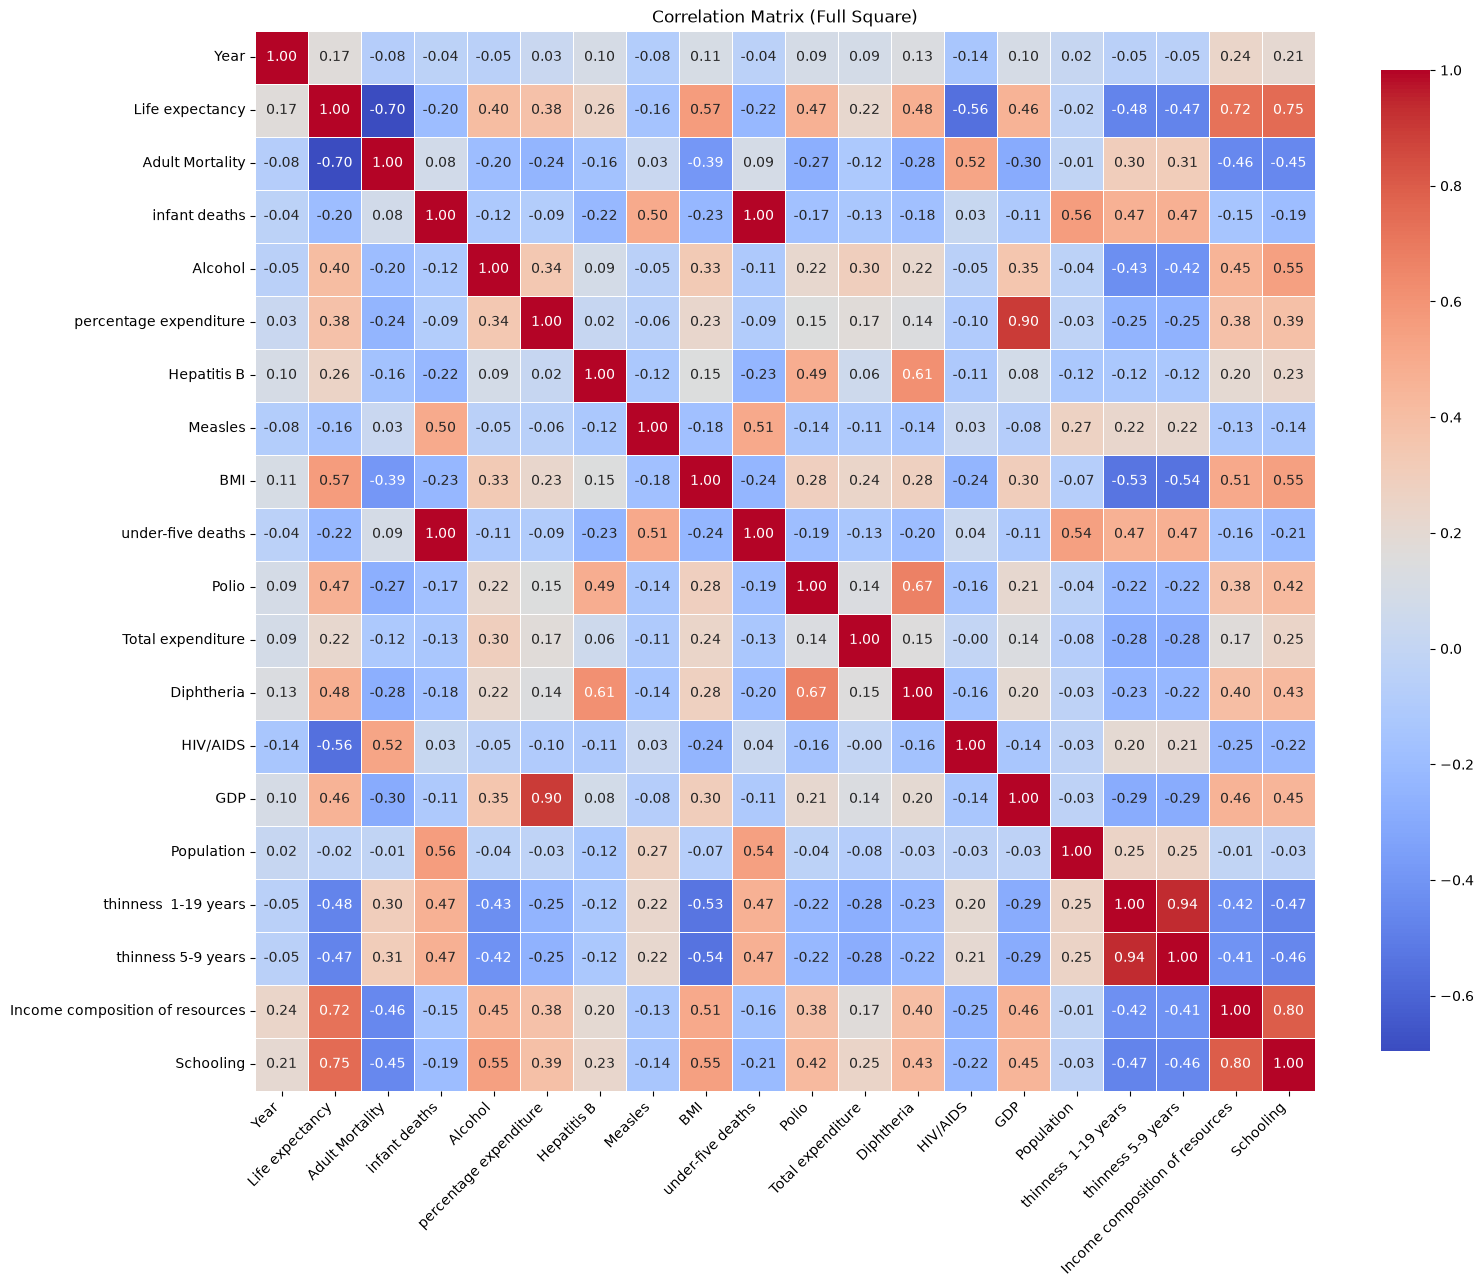

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = df.select_dtypes(include=['number'])
corr = num_cols.corr()

plt.figure(figsize=(16, 14))
sns.heatmap(
    corr, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title('Correlation Matrix (Full Square)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [4]:
import numpy as np

corr = df.select_dtypes(include='number').corr()

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
corr_pairs = corr.where(mask).stack().reset_index()
corr_pairs.columns = ['feature_1', 'feature_2', 'corr_value']

strong_corr = corr_pairs[corr_pairs['corr_value'].abs() > 0.7]
strong_corr = strong_corr.sort_values(
    'corr_value',
    key=abs,
    ascending=False
).reset_index(drop=True)

print(strong_corr)

                         feature_1                        feature_2  \
0                    infant deaths                under-five deaths   
1             thinness  1-19 years               thinness 5-9 years   
2           percentage expenditure                              GDP   
3  Income composition of resources                        Schooling   
4                  Life expectancy                        Schooling   
5                  Life expectancy  Income composition of resources   

   corr_value  
0        1.00  
1        0.94  
2        0.90  
3        0.80  
4        0.75  
5        0.72  


In [5]:
target = 'Life expectancy'

to_drop = ['percentage expenditure', 'under-five deaths',
           'thinness 5-9 years', 'Schooling']

df = df.drop(columns=to_drop)
df = df.dropna(subset=[target]).reset_index(drop=True)

train_df = df[df['Year'] <= 2013].copy()
val_df = df[df['Year'] == 2014].copy()
test_df = df[df['Year'] == 2015].copy()

features = [col for col in df.columns if col not in ['Year', target]]
cat_f = ['Status']
num_f = [col for col in features if col not in cat_f + ['Country']]

X_train, y_train = train_df[features], train_df[target]
X_val, y_val = val_df[features], val_df[target]
X_test, y_test = test_df[features], test_df[target]

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")


Train: (2562, 16), Val: (183, 16), Test: (183, 16)


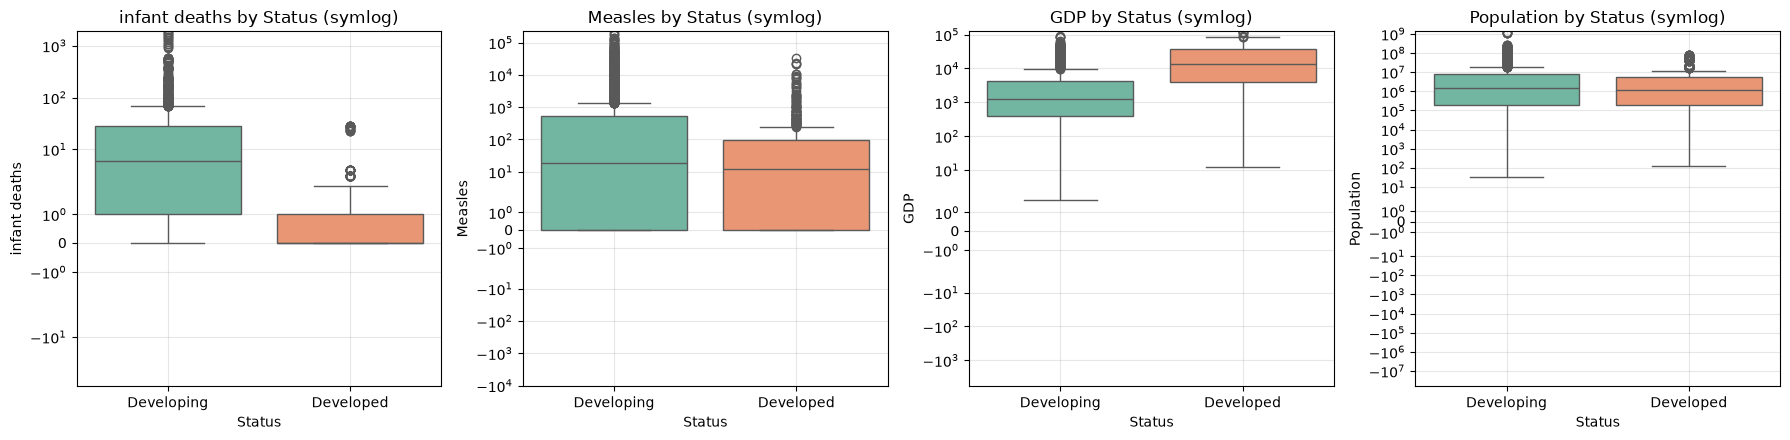

C:\Users\asus\AppData\Local\Temp\ipykernel_18704\1627910141.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Status', y=target, ax=axes[0], palette='Set2')


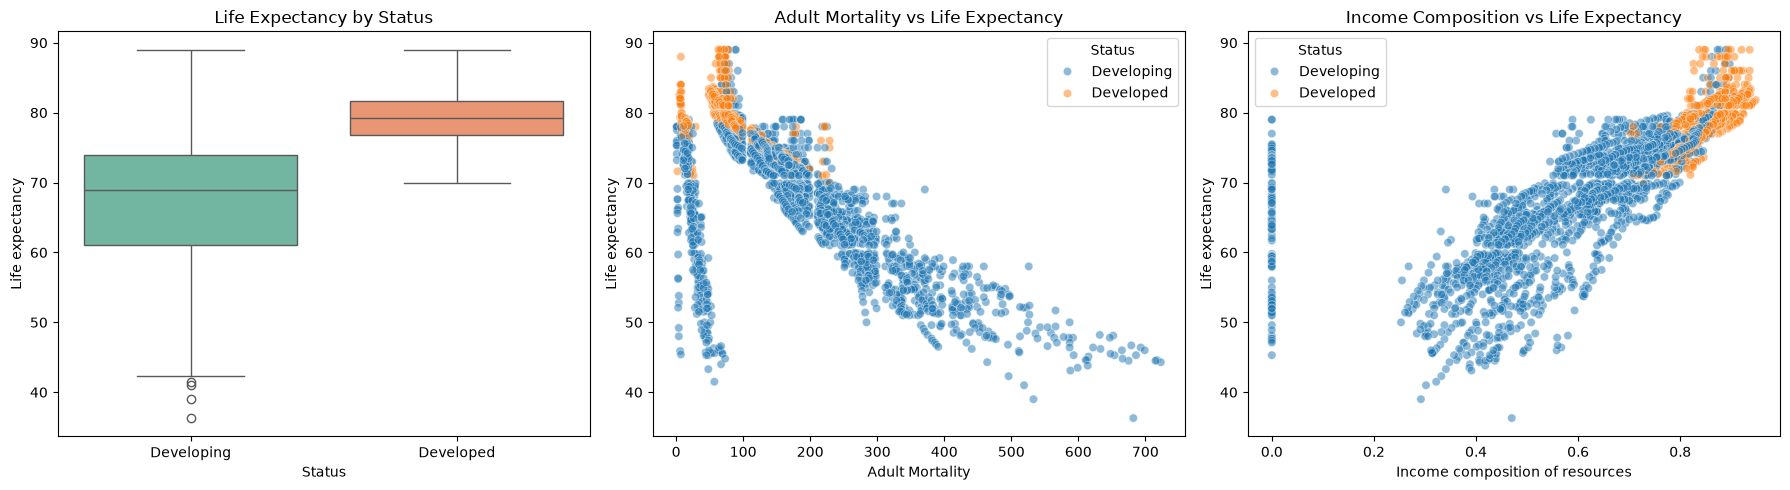

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

skewed_cols = ['infant deaths', 'Measles', 'GDP', 'Population']


fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, col in zip(axes, skewed_cols):
    sns.boxplot(data=df, x='Status', y=col, hue='Status',
                ax=ax, palette='Set2', legend=False)
    ax.set_yscale('symlog')
    ax.set_title(f'{col} by Status (symlog)')
    ax.set_ylabel(col)
    ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

# Фигура 2: связи с таргетом
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, x='Status', y=target, ax=axes[0], palette='Set2')
axes[0].set_title('Life Expectancy by Status')

sns.scatterplot(data=df, x='Adult Mortality', y=target,
                hue='Status', alpha=0.5, ax=axes[1])
axes[1].set_title('Adult Mortality vs Life Expectancy')

sns.scatterplot(data=df, x='Income composition of resources',
                y=target, hue='Status', alpha=0.5, ax=axes[2])
axes[2].set_title('Income Composition vs Life Expectancy')

plt.tight_layout()
plt.show()

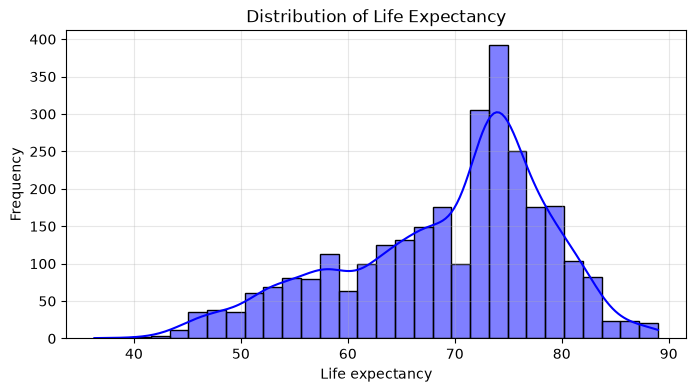

In [7]:

plt.figure(figsize=(8, 4))
sns.histplot(df[target], bins=30, kde=True, color='blue')
plt.title('Distribution of Life Expectancy')
plt.xlabel(target)
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.show()

In [8]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

class CountryStatusImputer(BaseEstimator, TransformerMixin):

    def __init__(self, country_col='Country', status_col='Status'):
        self.country_col = country_col
        self.status_col = status_col

    def fit(self, X, y=None):
        self.num_cols_ = list(
            X.drop(columns=[self.country_col, self.status_col])
             .select_dtypes(include='number').columns
        )
        self.country_mean_ = X.groupby(self.country_col)[self.num_cols_].mean()

        country_status = (
            X[[self.country_col, self.status_col]]
            .drop_duplicates()
            .set_index(self.country_col)[self.status_col]
        )
        self.status_median_ = self.country_mean_.groupby(country_status).median()
        self.global_median_ = X[self.num_cols_].median()
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.num_cols_:
            X[col] = (
                X[col]
                .fillna(X[self.country_col].map(self.country_mean_[col]))
                .fillna(X[self.status_col].map(self.status_median_[col]))
                .fillna(self.global_median_[col])
            )
        return X.drop(columns=[self.country_col])

In [9]:
import numpy as np
import pandas as pd
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


def get_preprocessor_linear():
    return Pipeline(steps=[
        ('imputer', CountryStatusImputer()),
        ('prep', ColumnTransformer(transformers=[
            ('num', StandardScaler(), num_f),
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_f),
        ])),
    ])


def get_preprocessor_tree():
    return Pipeline(steps=[
        ('imputer', CountryStatusImputer()),
        ('prep', ColumnTransformer(transformers=[
            ('num', 'passthrough', num_f),
            ('cat', OrdinalEncoder(handle_unknown='use_encoded_value',
                                   unknown_value=-1), cat_f),
        ])),
    ])
    

def evaluate_regression(model, X, y, model_name='Model'):
    preds = model.predict(X)
    mae = mean_absolute_error(y, preds)
    mse = mean_squared_error(y, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y, preds)
    eps = 1e-8
    mape = np.mean(np.abs((y - preds) / np.maximum(np.abs(y), eps))) * 100
    return {
        'Model': model_name,
        'MAE': round(mae, 4),
        'MSE': round(mse, 4),
        'RMSE': round(rmse, 4),
        'R2': round(r2, 4),
        'MAPE': round(mape, 4),
    }
    

In [10]:
import optuna
import lightgbm as lgb
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.dummy import DummyRegressor
from sklearn.base import clone

optuna.logging.set_verbosity(optuna.logging.WARNING)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

dummy_pipeline = Pipeline(steps=[
    ('preprocessor', get_preprocessor_tree()),
    ('model', DummyRegressor(strategy='mean'))
])
dummy_pipeline.fit(X_train, y_train)
results = [
    evaluate_regression(dummy_pipeline, X_train, y_train, 'Dummy_Train'),
    evaluate_regression(dummy_pipeline, X_val, y_val, 'Dummy_Val')
]

models_config = {
    'Ridge': {
        'pipe': Pipeline(steps=[('preprocessor', get_preprocessor_linear()), ('model', Ridge())]),
        'params': lambda t: {'model__alpha': t.suggest_float('model__alpha', 1e-3, 1e3, log=True)}
    },
    'DecisionTree': {
        'pipe': Pipeline(steps=[('preprocessor', get_preprocessor_tree()), ('model', DecisionTreeRegressor(random_state=42))]),
        'params': lambda t: {
            'model__max_depth': t.suggest_int('model__max_depth', 2, 10),
            'model__min_samples_split': t.suggest_int('model__min_samples_split', 2, 20),
            'model__min_samples_leaf': t.suggest_int('model__min_samples_leaf', 2, 10)
        }
    },
    'RandomForest': {
        'pipe': Pipeline(steps=[('preprocessor', get_preprocessor_tree()), ('model', RandomForestRegressor(random_state=42, n_jobs=-1))]),
        'params': lambda t: {
            'model__n_estimators': t.suggest_int('model__n_estimators', 50, 300),
            'model__max_depth': t.suggest_int('model__max_depth', 3, 10),
            'model__min_samples_leaf': t.suggest_int('model__min_samples_leaf', 2, 10),
            'model__max_features': t.suggest_categorical('model__max_features', ['sqrt', 'log2'])
        }
    },
    'GradientBoosting': {
        'pipe': Pipeline(steps=[('preprocessor', get_preprocessor_tree()), ('model', GradientBoostingRegressor(random_state=42))]),
        'params': lambda t: {
            'model__n_estimators': t.suggest_int('model__n_estimators', 100, 500),
            'model__learning_rate': t.suggest_float('model__learning_rate', 0.01, 0.3, log=True),
            'model__max_depth': t.suggest_int('model__max_depth', 3, 8),
            'model__subsample': t.suggest_float('model__subsample', 0.6, 1.0),
            'model__min_samples_leaf': t.suggest_int('model__min_samples_leaf', 2, 10),
            'model__validation_fraction': 0.1,
            'model__n_iter_no_change': 20,
            'model__tol': 1e-4
        }
    },
    'LightGBM': {
        'pipe': Pipeline(steps=[('preprocessor', get_preprocessor_tree()), ('model', lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1))]),
        'params': lambda t: {
            'model__n_estimators': t.suggest_int('model__n_estimators', 100, 300), 
            'model__learning_rate': t.suggest_float('model__learning_rate', 0.01, 0.3, log=True),
            'model__reg_alpha': t.suggest_float('model__reg_alpha', 1e-8, 10.0, log=True),
            'model__reg_lambda': t.suggest_float('model__reg_lambda', 1e-8, 10.0, log=True),
            'model__subsample': t.suggest_float('model__subsample', 0.6, 1.0),
            'model__colsample_bytree': t.suggest_float('model__colsample_bytree', 0.6, 1.0),
            'model__min_child_samples': t.suggest_int('model__min_child_samples', 5, 50)
        }
    }
}

best_models = {}

for name, config in models_config.items():
    pipe = config['pipe']
    
    def objective(trial, pipe=pipe, config=config):
        current_pipe = clone(pipe)
        params = config['params'](trial)
        current_pipe.set_params(**params)
        
        scores = cross_val_score(
            current_pipe, X_train, y_train, cv=kf, 
            scoring='neg_mean_absolute_error', n_jobs=-1
        )
        return -scores.mean()
        
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=50)
    
    pipe.set_params(**study.best_params)
    pipe.fit(X_train, y_train)
    best_models[name] = pipe
    results.append(evaluate_regression(pipe, X_train, y_train, f"{name}_Train"))
    results.append(evaluate_regression(pipe, X_val, y_val, f"{name}_Val"))

results_df = pd.DataFrame(results)
print(results_df)

                     Model  MAE   MSE  RMSE    R2  MAPE
0              Dummy_Train 7.90 92.83  9.63  0.00 12.43
1                Dummy_Val 7.58 79.90  8.94 -0.10 10.70
2              Ridge_Train 3.27 19.26  4.39  0.79  5.05
3                Ridge_Val 3.02 16.27  4.03  0.78  4.30
4       DecisionTree_Train 0.76  1.34  1.16  0.99  1.10
5         DecisionTree_Val 1.80  7.10  2.66  0.90  2.60
6       RandomForest_Train 0.94  1.94  1.39  0.98  1.44
7         RandomForest_Val 1.53  5.03  2.24  0.93  2.17
8   GradientBoosting_Train 0.24  0.12  0.35  1.00  0.35
9     GradientBoosting_Val 1.28  3.99  2.00  0.95  1.85
10          LightGBM_Train 0.41  0.36  0.60  1.00  0.60
11            LightGBM_Val 1.32  4.00  2.00  0.95  1.85


In [11]:
best_model_name = 'LightGBM'

try:
    best_pipe = best_models[best_model_name]
except NameError:
    print("Ошибка: словарь best_models не найден.")
    raise

test_metrics = evaluate_regression(best_pipe, X_test, y_test, f"{best_model_name}_Test")

final_report = results_df.copy()
final_report = pd.concat([final_report, pd.DataFrame([test_metrics])], ignore_index=True)

print(f"\n=== ФИНАЛЬНЫЙ РЕЗУЛЬТАТ НА ТЕСТЕ ===")
print(pd.DataFrame([test_metrics]))

print(f"\n=== СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ (по валидации) ===")
val_results = final_report[final_report['Model'].str.contains('_Val')]
print(val_results.sort_values(by='MAE', ascending=True))


=== ФИНАЛЬНЫЙ РЕЗУЛЬТАТ НА ТЕСТЕ ===
           Model  MAE  MSE  RMSE   R2  MAPE
0  LightGBM_Test 1.25 3.38  1.84 0.95  1.76

=== СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ (по валидации) ===
                   Model  MAE   MSE  RMSE    R2  MAPE
9   GradientBoosting_Val 1.28  3.99  2.00  0.95  1.85
11          LightGBM_Val 1.32  4.00  2.00  0.95  1.85
7       RandomForest_Val 1.53  5.03  2.24  0.93  2.17
5       DecisionTree_Val 1.80  7.10  2.66  0.90  2.60
3              Ridge_Val 3.02 16.27  4.03  0.78  4.30
1              Dummy_Val 7.58 79.90  8.94 -0.10 10.70


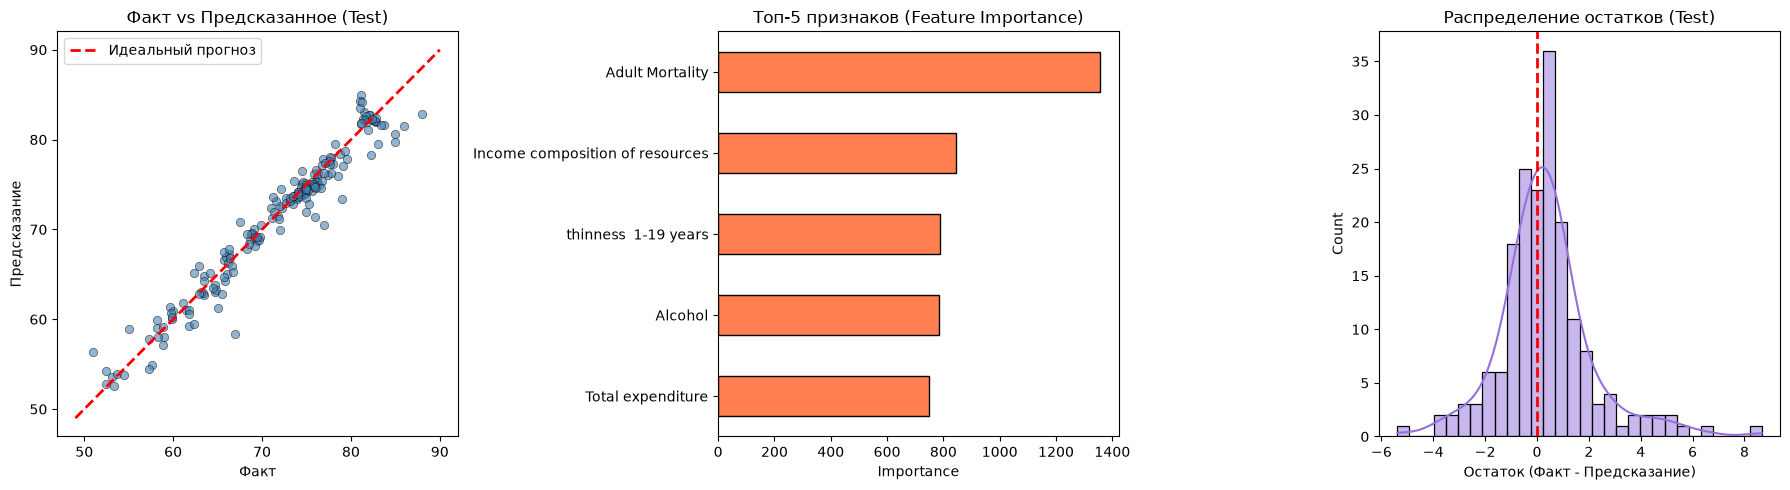


Остатки: mean=0.334, std=1.814


In [12]:
best_model_name = 'LightGBM'
best_pipe = best_models[best_model_name]

y_pred_test = best_pipe.predict(X_test)

preprocessor = best_pipe.named_steps['preprocessor']
ct = preprocessor.named_steps['prep']
feature_names = ct.get_feature_names_out()
feature_names = [f.replace('num__', '').replace('cat__', '') for f in feature_names]

importance = best_pipe.named_steps['model'].feature_importances_
feat_imp = pd.Series(importance, index=feature_names).sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_test, y_pred_test, alpha=0.6, color='steelblue', edgecolors='k', linewidths=0.5)
lims = [min(y_test.min(), y_pred_test.min()) - 2, max(y_test.max(), y_pred_test.max()) + 2]
axes[0].plot(lims, lims, 'r--', linewidth=2, label='Идеальный прогноз')
axes[0].set_xlabel('Факт')
axes[0].set_ylabel('Предсказание')
axes[0].set_title('Факт vs Предсказанное (Test)')
axes[0].legend()

feat_imp.head(5).plot(kind='barh', ax=axes[1], color='coral', edgecolor='k')
axes[1].set_title('Топ-5 признаков (Feature Importance)')
axes[1].set_xlabel('Importance')
axes[1].invert_yaxis()

residuals = y_test - y_pred_test
sns.histplot(residuals, bins=30, kde=True, ax=axes[2], color='mediumpurple', edgecolor='k')
axes[2].axvline(0, color='red', linestyle='--', linewidth=2)
axes[2].set_title('Распределение остатков (Test)')
axes[2].set_xlabel('Остаток (Факт - Предсказание)')

plt.tight_layout()
plt.savefig('final_report_plots.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nОстатки: mean={residuals.mean():.3f}, std={residuals.std():.3f}")

In [13]:
results_df['Base_Model'] = results_df['Model'].apply(lambda x: x.rsplit('_', 1)[0])

train_metrics = results_df[results_df['Model'].str.endswith('_Train')].set_index('Base_Model')
val_metrics = results_df[results_df['Model'].str.endswith('_Val')].set_index('Base_Model')

overfit_analysis = pd.DataFrame({
    'R2_Train': train_metrics['R2'],
    'R2_Val': val_metrics['R2'],
    'R2_Gap (Train - Val)': train_metrics['R2'] - val_metrics['R2'],
    'MAE_Train': train_metrics['MAE'],
    'MAE_Val': val_metrics['MAE']
}).sort_values('R2_Val', ascending=False)

overfit_analysis = overfit_analysis.round(3)

print("=== АНАЛИЗ ПЕРЕОБУЧЕНИЯ ===")
print(overfit_analysis)

=== АНАЛИЗ ПЕРЕОБУЧЕНИЯ ===
                  R2_Train  R2_Val  R2_Gap (Train - Val)  MAE_Train  MAE_Val
Base_Model                                                                  
GradientBoosting      1.00    0.94                  0.05       0.24     1.28
LightGBM              1.00    0.94                  0.05       0.41     1.32
RandomForest          0.98    0.93                  0.05       0.94     1.53
DecisionTree          0.99    0.90                  0.08       0.76     1.79
Ridge                 0.79    0.78                  0.02       3.27     3.02
Dummy                 0.00   -0.10                  0.10       7.90     7.58
